In [902]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [903]:
df = pd.read_csv('Amazon_Products.csv')

In [904]:
df.head()

,uniq_id,product_name,manufacturer,price,number_available_in_stock,number_of_reviews,number_of_answered_questions,average_review_rating,amazon_category_and_sub_category,description,...,Unnamed: 885,Unnamed: 886,Unnamed: 887,Unnamed: 888,Unnamed: 889,Unnamed: 890,Unnamed: 891,Unnamed: 892,Unnamed: 893,Unnamed: 894
0,eac7efa5dbd3d667f26eb3d3ab504464,Hornby 2014 Catalogue,Hornby,£3.42,5 new,15.0,1.0,4.9 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,Product Description Hornby 2014 Catalogue Box ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b17540ef7e86e461d37f3ae58b7b72ac,FunkyBuys® Large Christmas Holiday Express Fes...,FunkyBuys,£16.99,NaN,2.0,1.0,4.5 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,Size Name:Large FunkyBuys® Large Christmas Hol...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,348f344247b0c1a935b1223072ef9d8a,CLASSIC TOY TRAIN SET TRACK CARRIAGES LIGHT EN...,ccf,£9.99,2 new,17.0,2.0,3.9 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,BIG CLASSIC TOY TRAIN SET TRACK CARRIAGE LIGHT...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,e12b92dbb8eaee78b22965d2a9bbbd9f,HORNBY Coach R4410A BR Hawksworth Corridor 3rd,Hornby,£39.99,NaN,1.0,2.0,5.0 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,Hornby 00 Gauge BR Hawksworth 3rd Class W 2107...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,e33a9adeed5f36840ccc227db4682a36,Hornby 00 Gauge 0-4-0 Gildenlow Salt Co. Steam...,Hornby,£32.19,NaN,3.0,2.0,4.7 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,Product Description Hornby RailRoad 0-4-0 Gild...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [905]:
df.columns

Index(['uniq_id', 'product_name', 'manufacturer', 'price',
       'number_available_in_stock', 'number_of_reviews',
       'number_of_answered_questions', 'average_review_rating',
       'amazon_category_and_sub_category', 'description',
       ...
       'Unnamed: 885', 'Unnamed: 886', 'Unnamed: 887', 'Unnamed: 888',
       'Unnamed: 889', 'Unnamed: 890', 'Unnamed: 891', 'Unnamed: 892',
       'Unnamed: 893', 'Unnamed: 894'],
      dtype='str', length=895)

In [906]:
df = df[['manufacturer', 'price', 'number_available_in_stock', 'number_of_reviews', 'number_of_answered_questions', 'average_review_rating', 'amazon_category_and_sub_category']]
df.shape

(10004, 7)

In [907]:
df.isnull().sum()

manufacturer                           9
price                               1437
number_available_in_stock           2502
number_of_reviews                     20
number_of_answered_questions         767
average_review_rating                 20
amazon_category_and_sub_category     692
dtype: int64

In [908]:
df.info

<bound method DataFrame.info of                   manufacturer   price number_available_in_stock  \
0                       Hornby   £3.42                     5 new   
1                    FunkyBuys  £16.99                       NaN   
2                          ccf   £9.99                     2 new   
3                       Hornby  £39.99                       NaN   
4                       Hornby  £32.19                       NaN   
...                        ...     ...                       ...   
9999                    Mattel  £22.95                     5 new   
10000                Star Wars  £39.99                       NaN   
10001  Olde Scotland Yard Ltd.  £43.99                     3 new   
10002                DC Comics  £49.81                     3 new   
10003                   Bandai  £21.20                    31 new   

      number_of_reviews number_of_answered_questions average_review_rating  \
0                  15.0                          1.0    4.9 out of 5 star

In [909]:
df.describe()

,manufacturer,price,number_available_in_stock,number_of_reviews,number_of_answered_questions,average_review_rating,amazon_category_and_sub_category
count,9995,8567,7502,9984.0,9237.0,9984,9312
unique,2652,2626,90,290.0,30.0,20,256
top,LEGO,£9.99,2 new,1.0,1.0,5.0 out of 5 stars,Die-Cast & Toy Vehicles > Toy Vehicles & Acces...
freq,171,189,1337,3143.0,5796.0,5140,880


In [910]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10004 entries, 0 to 10003
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   manufacturer                      9995 non-null   str   
 1   price                             8567 non-null   str   
 2   number_available_in_stock         7502 non-null   str   
 3   number_of_reviews                 9984 non-null   object
 4   number_of_answered_questions      9237 non-null   object
 5   average_review_rating             9984 non-null   str   
 6   amazon_category_and_sub_category  9312 non-null   str   
dtypes: object(2), str(5)
memory usage: 1.3+ MB


In [911]:
df['price'] = df['price'].str.replace('£', '')
df['price'] = df['price'].str.replace(',', '')

In [912]:
df["price"].value_counts()

price
9.99     189
4.99     140
14.99    132
6.99     126
5.99     126
        ... 
31.14      1
25.33      1
29.79      1
49.81      1
21.20      1
Name: count, Length: 2626, dtype: int64

In [913]:
print(df["price"].apply(type).value_counts())

price
<class 'str'>      8567
<class 'float'>    1437
Name: count, dtype: int64


In [914]:
df["price"] = df["price"].astype(str)
print(df["price"].apply(type).value_counts())
print(df["price"].dtype)

price
<class 'str'>      8567
<class 'float'>    1437
Name: count, dtype: int64
str


In [915]:
df.loc[df["price"].str.contains('subtext', na=False), 'price'] = pd.NA
df["price"].str.contains('subtext', na=False).sum()

np.int64(0)

In [916]:
def average_range(x):
    if pd.isna(x):
        return x

    if isinstance(x, (int, float)):
        return float(x)

    x = str(x).strip()
    if "-" in x:
        low, high = x.split("-", 1)
        return (float(low.strip()) + float(high.strip())) / 2

    return float(x)

df["price"] = df["price"].apply(average_range)


In [917]:
df["price"].isnull().sum()

np.int64(1439)

In [918]:
df['price'] = df['price'].fillna(df['price'].mean())

In [919]:
df["price"].isnull().sum()


np.int64(0)

In [920]:
df['price'] = df['price'].astype(float)

Text(0.5, 1.0, 'Distribution of Price')

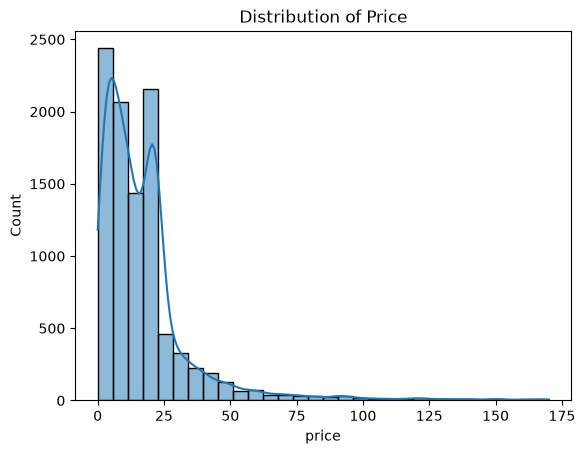

In [921]:
filtered_df = df[df['price'] <= 169.99]
sns.histplot(data=filtered_df, x='price', bins=30, kde=True)
plt.title('Distribution of Price')

In [922]:
print((df['price'] == 0).sum())
print(df['price'].quantile(0.99))
print(df['price'].max())

0
169.99
8140.3


In [923]:
df = df.loc[df['price'] <= 169.99] # we only want to keep the products that are priced at or below £169.99, which is the 99th percentile of the price distribution.

<Axes: xlabel='price', ylabel='Count'>

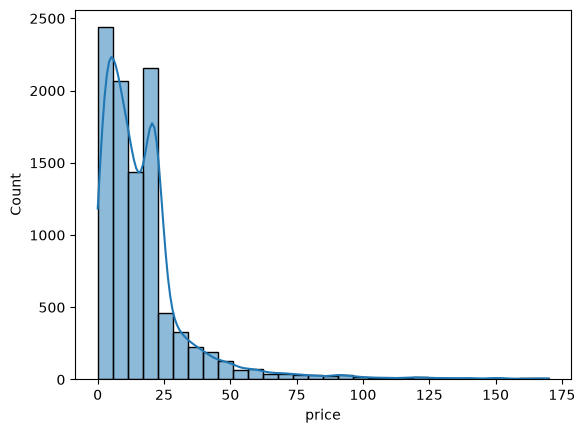

In [924]:
sns.histplot(df['price'], bins=30, kde=True)

In [925]:
df['manufacturer'].nunique()

2635

In [926]:
df.drop_duplicates(inplace=True)

In [927]:
df.columns

Index(['manufacturer', 'price', 'number_available_in_stock',
       'number_of_reviews', 'number_of_answered_questions',
       'average_review_rating', 'amazon_category_and_sub_category'],
      dtype='str')

In [928]:
df["number_available_in_stock"].isnull().sum()



np.int64(2373)

In [929]:
df['number_available_in_stock'].value_counts()

number_available_in_stock
2 new      1312
3 new       963
4 new       745
5 new       583
6 new       468
           ... 
66 new        1
62 new        1
70 new        1
12 used       1
9 used        1
Name: count, Length: 90, dtype: int64

In [930]:
df["number_available_in_stock"].unique()[:20]

<ArrowStringArray>
[ '5 new',      nan,  '2 new',  '3 new',  '1 new',  '6 new', '18 new',
 '12 new', '1 used', '26 new', '37 new', '35 new',  '4 new', '22 new',
 '11 new', '16 new', '31 new',  '9 new', '29 new', '33 new']
Length: 20, dtype: str

In [931]:
df[["stock", "condition"]] = (
    df["number_available_in_stock"]
    .str.split("\xa0", n=1, expand=True)
)

In [932]:
print(repr(df["number_available_in_stock"].dropna().iloc[0]))

'5\xa0new'


In [933]:
df.head()

,manufacturer,price,number_available_in_stock,number_of_reviews,number_of_answered_questions,average_review_rating,amazon_category_and_sub_category,stock,condition
0,Hornby,3.42,5 new,15.0,1.0,4.9 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,5,new
1,FunkyBuys,16.99,NaN,2.0,1.0,4.5 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,NaN,NaN
2,ccf,9.99,2 new,17.0,2.0,3.9 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,2,new
3,Hornby,39.99,NaN,1.0,2.0,5.0 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,NaN,NaN
4,Hornby,32.19,NaN,3.0,2.0,4.7 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,NaN,NaN


In [934]:
df["condition"].value_counts()

condition
new            7225
used            158
collectible      13
refurbished       2
Name: count, dtype: int64

In [935]:
df['condition'].isnull().sum()

np.int64(2374)

In [936]:
df.drop(columns=["number_available_in_stock"], inplace=True)

In [937]:
df["condition"] = df["condition"].fillna("Unknown")

In [938]:
df[df["stock"].isna()].head(10)

,manufacturer,price,number_of_reviews,number_of_answered_questions,average_review_rating,amazon_category_and_sub_category,stock,condition
1,FunkyBuys,16.99,2.0,1.0,4.5 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,NaN,Unknown
3,Hornby,39.99,1.0,2.0,5.0 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,NaN,Unknown
4,Hornby,32.19,3.0,2.0,4.7 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,NaN,Unknown
5,Generic,6.99,2.0,1.0,5.0 out of 5 stars,Hobbies > Model Trains & Railway Sets > Lighti...,NaN,Unknown
6,Hornby,24.99,2.0,1.0,4.5 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,NaN,Unknown
20,Preiser,27.55,1.0,1.0,5.0 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,NaN,Unknown
22,Bachmann,149.92,1.0,1.0,5.0 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,NaN,Unknown
24,Roco,49.95,1.0,1.0,5.0 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,NaN,Unknown
29,Gaugemaster,5.95,5.0,1.0,4.8 out of 5 stars,Hobbies > Model Trains & Railway Sets > Lighti...,NaN,Unknown
31,Fisher-Price,19.99,3.0,1.0,5.0 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,NaN,Unknown


In [939]:
df["stock_missing"] = df["stock"].isna().astype(int)

In [940]:
df["stock"].dtype

<StringDtype(na_value=nan)>

In [941]:
df["stock"] = pd.to_numeric(df["stock"], errors="coerce")

In [942]:
df["stock"].dtype

dtype('float64')

In [943]:
df["stock"] = df["stock"].fillna(df["stock"].median())
df["stock"] = df["stock"].astype(int)

In [944]:
df.head()

,manufacturer,price,number_of_reviews,number_of_answered_questions,average_review_rating,amazon_category_and_sub_category,stock,condition,stock_missing
0,Hornby,3.42,15.0,1.0,4.9 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,5,new,0
1,FunkyBuys,16.99,2.0,1.0,4.5 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,5,Unknown,1
2,ccf,9.99,17.0,2.0,3.9 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,2,new,0
3,Hornby,39.99,1.0,2.0,5.0 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,5,Unknown,1
4,Hornby,32.19,3.0,2.0,4.7 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,5,Unknown,1


<Axes: xlabel='stock', ylabel='Count'>

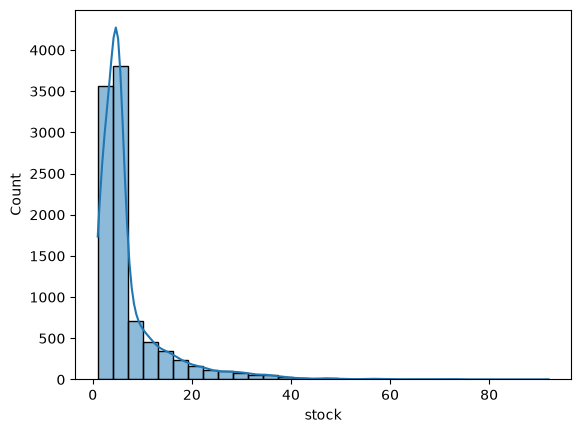

In [945]:
sns.histplot(df['stock'], bins=30, kde=True)

In [946]:
df['number_of_reviews'].isnull().sum()

np.int64(19)

In [947]:
df['number_of_reviews'].str.contains('subtext', na=False).dropna().sum()

np.int64(1)

In [948]:
df.loc[df['number_of_reviews'].str.contains('subtext', na=False), 'number_of_reviews'] = pd.NA

In [949]:
df['number_of_reviews'].str.contains('subtext', na=False).dropna().sum()


np.int64(0)

In [950]:
df['number_of_reviews'] = df['number_of_reviews'].fillna(0)

In [951]:
df['number_of_reviews'].isnull().sum()

np.int64(0)

In [952]:
df['number_of_reviews'] = df['number_of_reviews'].astype(str).str.replace(',', '')

In [953]:
df['number_of_reviews'].isnull().sum()

np.int64(0)

In [954]:
df["number_of_reviews"] = pd.to_numeric(
    df["number_of_reviews"],
    errors="coerce"
)

In [955]:
df['number_of_reviews'] = df['number_of_reviews'].astype(int)

<Axes: xlabel='number_of_reviews_log', ylabel='Count'>

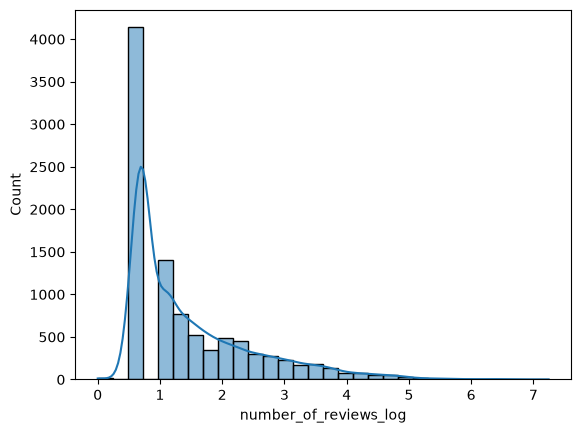

In [956]:
df["number_of_reviews_log"] = np.log1p(df["number_of_reviews"])
sns.histplot(df['number_of_reviews_log'], bins=30, kde=True)

In [957]:
print((df['number_of_reviews'] == 0).sum())
print(df['number_of_reviews'].quantile(0.99))
print(df['number_of_reviews'].max())

20
116.0
1399


In [958]:
df['number_of_answered_questions'].isnull().sum()

np.int64(754)

In [959]:
print(df["number_of_answered_questions"].apply(type).value_counts())

number_of_answered_questions
<class 'float'>    8854
<class 'str'>       918
Name: count, dtype: int64


In [960]:
df["number_of_answered_questions"].value_counts()

number_of_answered_questions
1.0                             5630
2.0                             1367
1                                618
3.0                              474
4.0                              195
5.0                              157
2                                 87
3                                 84
6.0                               79
11.0                              59
9.0                               45
7.0                               39
4                                 39
13.0                              21
11                                20
23                                14
39                                14
19.0                              12
12.0                              12
10                                 9
9                                  9
12                                 9
8.0                                7
7                                  6
28                                 4
5                                  3
10.0     

In [961]:
df['number_of_answered_questions'] = df['number_of_answered_questions'].fillna(0)

In [962]:
df['number_of_answered_questions'].isnull().sum()

np.int64(0)

In [963]:
df[ df['number_of_answered_questions'].str.contains("panel", na=False) ].head(10)

,manufacturer,price,number_of_reviews,number_of_answered_questions,average_review_rating,amazon_category_and_sub_category,stock,condition,stock_missing,number_of_reviews_log
2003,"panelKey"""":""""Mp3Panel""""}",21.277876,0,"panelKey"""":""""AndroidPanel""""}","{""""text"""":""""Amazon Cloud Drive""""","panelKey"""":""""CloudDrivePanel""""}",5,Unknown,0,0.0


In [964]:
df.drop(index=2003, inplace=True)


In [965]:
df[ df['number_of_answered_questions'].str.contains("panel", na=False) ].head(10)

,manufacturer,price,number_of_reviews,number_of_answered_questions,average_review_rating,amazon_category_and_sub_category,stock,condition,stock_missing,number_of_reviews_log


In [966]:
df['number_of_answered_questions'] = pd.to_numeric(df["number_of_answered_questions"], errors="coerce")

In [967]:
df['number_of_answered_questions'] = df['number_of_answered_questions'].astype(int)

In [968]:
df.head()

,manufacturer,price,number_of_reviews,number_of_answered_questions,average_review_rating,amazon_category_and_sub_category,stock,condition,stock_missing,number_of_reviews_log
0,Hornby,3.42,15,1,4.9 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,5,new,0,2.772589
1,FunkyBuys,16.99,2,1,4.5 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,5,Unknown,1,1.098612
2,ccf,9.99,17,2,3.9 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,2,new,0,2.890372
3,Hornby,39.99,1,2,5.0 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,5,Unknown,1,0.693147
4,Hornby,32.19,3,2,4.7 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,5,Unknown,1,1.386294


In [969]:
df["average_review_rating"].isnull().sum()

np.int64(19)

In [970]:
df['average_review_rating'].value_counts().sum

<bound method Series.sum of average_review_rating
5.0 out of 5 stars    4952
4.0 out of 5 stars    1293
4.5 out of 5 stars     715
4.8 out of 5 stars     562
4.7 out of 5 stars     526
4.3 out of 5 stars     405
4.6 out of 5 stars     390
4.4 out of 5 stars     296
4.9 out of 5 stars     235
4.2 out of 5 stars     214
4.1 out of 5 stars     144
3.9 out of 5 stars       7
3.0 out of 5 stars       3
3.6 out of 5 stars       3
3.5 out of 5 stars       2
3.7 out of 5 stars       2
3.8 out of 5 stars       1
2.3 out of 5 stars       1
3.3 out of 5 stars       1
Name: count, dtype: int64>

In [971]:
df['average_review_rating'] = df['average_review_rating'].str.replace(' out of 5 stars', '', regex=False)

In [972]:
df['average_review_rating'] = pd.to_numeric(df['average_review_rating'], errors='coerce')

In [973]:
df['average_review_rating'] = df['average_review_rating'].astype(float)

In [974]:
df['average_review_rating'] = df['average_review_rating'].fillna(df['average_review_rating'].mean())

In [975]:
df.head()

,manufacturer,price,number_of_reviews,number_of_answered_questions,average_review_rating,amazon_category_and_sub_category,stock,condition,stock_missing,number_of_reviews_log
0,Hornby,3.42,15,1,4.9,Hobbies > Model Trains & Railway Sets > Rail V...,5,new,0,2.772589
1,FunkyBuys,16.99,2,1,4.5,Hobbies > Model Trains & Railway Sets > Rail V...,5,Unknown,1,1.098612
2,ccf,9.99,17,2,3.9,Hobbies > Model Trains & Railway Sets > Rail V...,2,new,0,2.890372
3,Hornby,39.99,1,2,5.0,Hobbies > Model Trains & Railway Sets > Rail V...,5,Unknown,1,0.693147
4,Hornby,32.19,3,2,4.7,Hobbies > Model Trains & Railway Sets > Rail V...,5,Unknown,1,1.386294


In [976]:
df["amazon_category_and_sub_category"].nunique()

255

In [977]:
df["amazon_category_and_sub_category"].str.count(">").max()

np.float64(4.0)

In [978]:
df["amazon_category_and_sub_category"].str.count(">").min()

np.float64(1.0)

In [979]:
df["amazon_category_and_sub_category"].isnull().sum()   

np.int64(679)

In [980]:
print(df["amazon_category_and_sub_category"].sample(10).to_list())

['Hobbies > Model Trains & Railway Sets > Rail Vehicles > Trains', 'Sports Toys & Outdoor > Kites & Flight Toys', 'Figures & Playsets > Knights & Castles', 'Party Supplies > Decorations > Balloons', 'Novelty & Special Use > Novelty', 'Hobbies > Model Trains & Railway Sets > Rail Vehicles > Locomotives', 'Characters & Brands > Hasbro', nan, 'Characters & Brands > Star Wars > Toys', 'Die-Cast & Toy Vehicles > Toy Vehicles & Accessories > Scaled Models > Vehicles']


In [981]:
df["amazon_category_and_sub_category"].str.split(">").str.len().value_counts()

amazon_category_and_sub_category
3.0    3887
2.0    3849
4.0    1272
5.0      84
Name: count, dtype: int64

In [982]:
categories = df["amazon_category_and_sub_category"].str.split(">", expand=True)

categories.columns = [
    "cat1",
    "cat2",
    "cat3",
    "cat4",
    "cat5"
][:categories.shape[1]]

categories = categories.apply(lambda col: col.str.strip())

selected_columns = ["cat1", "cat2"]
selected_categories = categories[selected_columns]

In [983]:
selected_categories

,cat1,cat2
0,Hobbies,Model Trains & Railway Sets
1,Hobbies,Model Trains & Railway Sets
2,Hobbies,Model Trains & Railway Sets
3,Hobbies,Model Trains & Railway Sets
4,Hobbies,Model Trains & Railway Sets
...,...,...
9999,Hobbies,Collectible Figures & Memorabilia
10000,Characters & Brands,Star Wars
10001,Novelty & Special Use,Novelty
10002,Hobbies,Collectible Figures & Memorabilia


In [984]:
df[['cat1', 'cat2']] = selected_categories

In [985]:
df.head()

,manufacturer,price,number_of_reviews,number_of_answered_questions,average_review_rating,amazon_category_and_sub_category,stock,condition,stock_missing,number_of_reviews_log,cat1,cat2
0,Hornby,3.42,15,1,4.9,Hobbies > Model Trains & Railway Sets > Rail V...,5,new,0,2.772589,Hobbies,Model Trains & Railway Sets
1,FunkyBuys,16.99,2,1,4.5,Hobbies > Model Trains & Railway Sets > Rail V...,5,Unknown,1,1.098612,Hobbies,Model Trains & Railway Sets
2,ccf,9.99,17,2,3.9,Hobbies > Model Trains & Railway Sets > Rail V...,2,new,0,2.890372,Hobbies,Model Trains & Railway Sets
3,Hornby,39.99,1,2,5.0,Hobbies > Model Trains & Railway Sets > Rail V...,5,Unknown,1,0.693147,Hobbies,Model Trains & Railway Sets
4,Hornby,32.19,3,2,4.7,Hobbies > Model Trains & Railway Sets > Rail V...,5,Unknown,1,1.386294,Hobbies,Model Trains & Railway Sets


In [986]:
df.drop(columns=["amazon_category_and_sub_category"], inplace=True)

In [987]:
df.head()

,manufacturer,price,number_of_reviews,number_of_answered_questions,average_review_rating,stock,condition,stock_missing,number_of_reviews_log,cat1,cat2
0,Hornby,3.42,15,1,4.9,5,new,0,2.772589,Hobbies,Model Trains & Railway Sets
1,FunkyBuys,16.99,2,1,4.5,5,Unknown,1,1.098612,Hobbies,Model Trains & Railway Sets
2,ccf,9.99,17,2,3.9,2,new,0,2.890372,Hobbies,Model Trains & Railway Sets
3,Hornby,39.99,1,2,5.0,5,Unknown,1,0.693147,Hobbies,Model Trains & Railway Sets
4,Hornby,32.19,3,2,4.7,5,Unknown,1,1.386294,Hobbies,Model Trains & Railway Sets


In [988]:
df["cat1"].nunique()

43

In [989]:
df['cat2'].nunique()

148

In [990]:
df['condition'].value_counts()

condition
new            7225
Unknown        2373
used            158
collectible      13
refurbished       2
Name: count, dtype: int64

In [991]:
df =  pd.get_dummies(df, columns=['condition'], prefix='condition', dtype=int)

In [992]:
df.columns  

Index(['manufacturer', 'price', 'number_of_reviews',
       'number_of_answered_questions', 'average_review_rating', 'stock',
       'stock_missing', 'number_of_reviews_log', 'cat1', 'cat2',
       'condition_Unknown', 'condition_collectible', 'condition_new',
       'condition_refurbished', 'condition_used'],
      dtype='str')

In [993]:
df_model1 = df[['price',
       'number_of_answered_questions', 'average_review_rating', 'stock',
       'stock_missing', 'number_of_reviews_log',
       'condition_Unknown', 'condition_collectible', 'condition_new',
       'condition_refurbished', 'condition_used']]

In [994]:
df_model1.info()

<class 'pandas.DataFrame'>
Index: 9771 entries, 0 to 10003
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   price                         9771 non-null   float64
 1   number_of_answered_questions  9771 non-null   int64  
 2   average_review_rating         9771 non-null   float64
 3   stock                         9771 non-null   int64  
 4   stock_missing                 9771 non-null   int64  
 5   number_of_reviews_log         9771 non-null   float64
 6   condition_Unknown             9771 non-null   int64  
 7   condition_collectible         9771 non-null   int64  
 8   condition_new                 9771 non-null   int64  
 9   condition_refurbished         9771 non-null   int64  
 10  condition_used                9771 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 916.0 KB


In [995]:
X = df_model1.drop(columns=["price"])
y = df_model1["price"]

<Axes: >

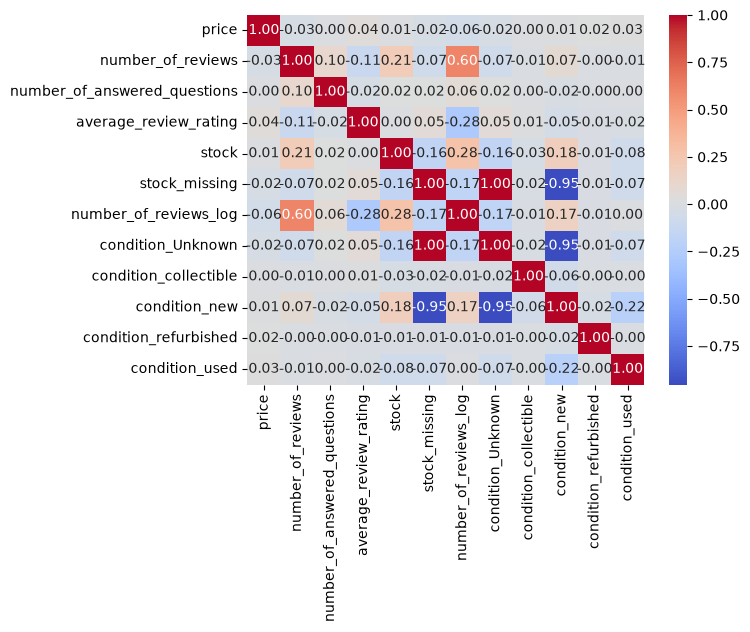

In [996]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")

In [997]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [998]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.01, 1.7 , 0.04,...,-11.69, 37.97, -6.42]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['number_of_answered_questions','average_review_rating','stock',..., 'condition_new','condition_refurbished','condition_used']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,23.32
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [999]:
y_pred = model_lr.predict(X_test)

In [1000]:
from sklearn.metrics import mean_squared_error, r2_score

In [1001]:
r2 = r2_score(y_test, y_pred)
r2

-0.0028740091840071536

In [1002]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
dt = DecisionTreeRegressor(random_state=42)

TypeError: DecisionTreeRegressor.__init__() got an unexpected keyword argument 'n_estimators'

In [1004]:
dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [1005]:
y_pred = dt.predict(X_test)
accuracy = dt.score(X_test, y_test)
accuracy

-0.3492650516846618

In [1006]:
df_model2 = df[['price',
       'number_of_answered_questions', 'average_review_rating', 'stock',
       'stock_missing', 'number_of_reviews_log',
       'condition_Unknown', 'condition_collectible', 'condition_new',
       'condition_refurbished', 'condition_used', 'cat1', 'cat2']]

In [1007]:
df_model2 = pd.get_dummies(df_model2, columns=['cat1', 'cat2'], prefix=['cat1', 'cat2'], dtype=int)

In [1008]:
X = df_model2.drop(columns=["price"])
y = df_model2["price"]

In [1009]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [1010]:
dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [1011]:
dt.score(X_test, y_test)

-0.43220637153927255

<Axes: xlabel='price', ylabel='Count'>

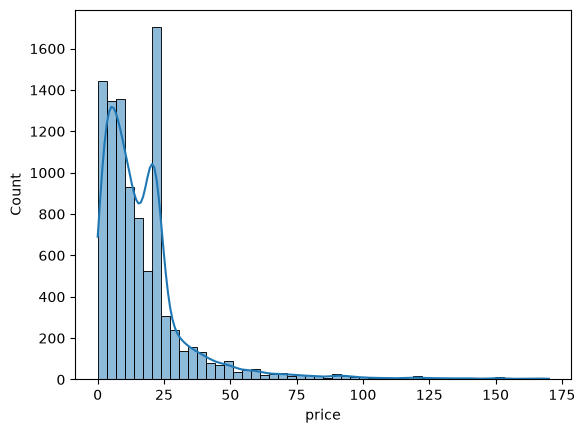

In [1012]:
import seaborn as sns

sns.histplot(df["price"], bins=50, kde=True)

In [1013]:
df["price"].describe()

count    9771.000000
mean       17.697046
std        19.785642
min         0.010000
25%         5.950000
50%        12.990000
75%        21.277876
max       169.990000
Name: price, dtype: float64

In [1014]:
print(df["price"].nlargest(20))

132     169.99
2556    169.99
4060    169.99
9118    169.99
3549    169.95
1693    168.50
6425    167.61
59      167.10
137     166.04
6798    166.03
3526    163.99
109     163.88
8861    162.53
6430    162.01
1670    161.22
369     160.00
7778    159.99
2348    159.96
2399    156.95
7962    156.11
Name: price, dtype: float64


In [1015]:
print("Train R²:", dt.score(X_train, y_train))
print("Test  R²:", dt.score(X_test, y_test))

Train R²: 0.6547520610381679
Test  R²: -0.43220637153927255


In [1016]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    dt,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.Series(
    result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(15))

cat1_Party Supplies                       0.139110
average_review_rating                     0.127912
stock                                     0.100467
cat2_Toy Vehicles & Accessories           0.074957
number_of_reviews_log                     0.071706
cat1_Arts & Crafts                        0.069521
cat2_Card Games                           0.031611
condition_Unknown                         0.025316
cat2_Model Trains & Railway Sets          0.025066
cat2_Collectible Figures & Memorabilia    0.019981
condition_new                             0.019829
cat2_Dice & Dice Games                    0.019142
number_of_answered_questions              0.018205
cat2_Star Wars                            0.015191
cat1_Jigsaws & Puzzles                    0.012013
dtype: float64


In [1020]:
from sklearn.preprocessing import StandardScaler

In [1023]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [1024]:
model_lr.fit(X_train_scaled, y_train)
y_pred= model_lr.predict(X_test_scaled)

In [1025]:
r2 = r2_score(y_test, y_pred)
r2

0.1489032499402363

In [1027]:
from sklearn.ensemble import RandomForestRegressor

In [1028]:
rf = RandomForestRegressor(    random_state=42,
    n_estimators=200)

In [1031]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [1032]:
rf.score(X_test, y_test)

0.0570964890834148

In [1033]:
top_manufacturers = df["manufacturer"].value_counts().nlargest(50).index

df["manufacturer"] = df["manufacturer"].where(
    df["manufacturer"].isin(top_manufacturers),
    "Other"
)

In [1034]:
df.head()

,manufacturer,price,number_of_reviews,number_of_answered_questions,average_review_rating,stock,stock_missing,number_of_reviews_log,cat1,cat2,condition_Unknown,condition_collectible,condition_new,condition_refurbished,condition_used
0,Hornby,3.42,15,1,4.9,5,0,2.772589,Hobbies,Model Trains & Railway Sets,0,0,1,0,0
1,Other,16.99,2,1,4.5,5,1,1.098612,Hobbies,Model Trains & Railway Sets,1,0,0,0,0
2,Other,9.99,17,2,3.9,2,0,2.890372,Hobbies,Model Trains & Railway Sets,0,0,1,0,0
3,Hornby,39.99,1,2,5.0,5,1,0.693147,Hobbies,Model Trains & Railway Sets,1,0,0,0,0
4,Hornby,32.19,3,2,4.7,5,1,1.386294,Hobbies,Model Trains & Railway Sets,1,0,0,0,0


In [ ]:
df = pd.get_dummies(df, columns=['manufacturer'], prefix='manufacturer', dtype=int)
df = pd.get_dummies(df, columns=['cat1', 'cat2'], prefix=['cat1', 'cat2'], dtype=int)

In [1042]:
X = df.drop(columns=["price"])
y = df["price"]

In [1043]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [1044]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [1045]:
rf.score(X_test, y_test)

0.11983801069056876